In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
x = 6 * np.random.rand(200, 1) -3
y = 0.8*(x**2) + 0.9*x + 2 + np.random.rand(200, 1)

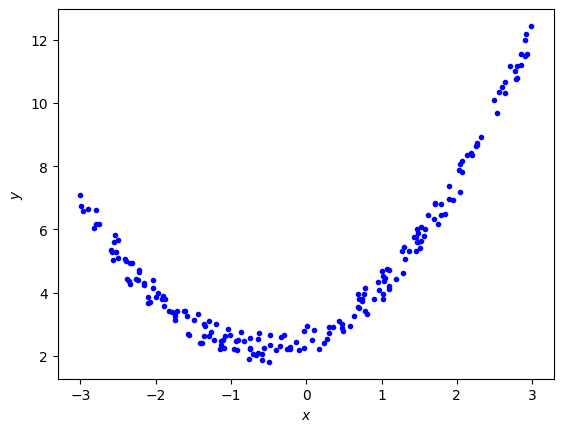

In [4]:
plt.plot(x, y, 'b.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

# **Simple Linear Regression**

In [6]:
lr = LinearRegression()
lr.fit(x_train , y_train)

LinearRegression()

In [8]:
y_pred = lr.predict(x_test)

r2_score(y_test , y_pred)
# r2_score is negative that means it is way too worse as it cannot explain the data correctly

-0.07707779407067306

visulaizing regression line

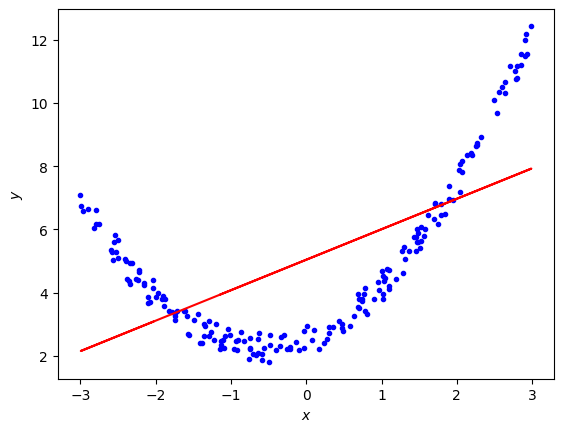

In [10]:
plt.plot(x , y , 'b.')
plt.plot(x_train , lr.predict(x_train) , 'r-')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

# **Polynomial Linear Regression**

In [17]:
poly = PolynomialFeatures(degree=2 , include_bias=True)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

# training polynomial regression
lr.fit(x_train_trans , y_train)
y_pred = lr.predict(x_test_trans)

r2_score(y_test , y_pred)

0.9828611302611047

In [12]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.90687062 0.79135855]]
[2.55792916]


visualizing regression line

In [16]:
x_train.shape

(160, 1)

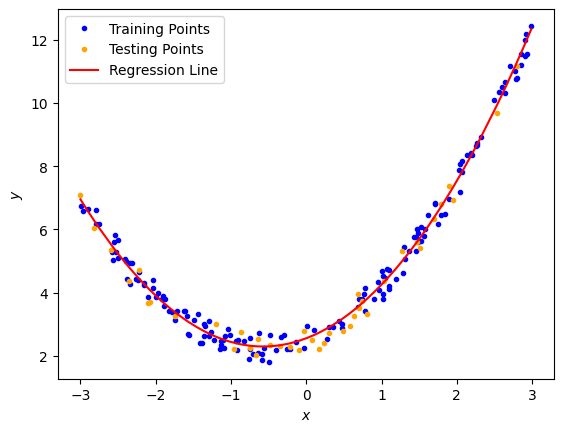

In [22]:
plt.plot(x_train , y_train , 'b.' , label = 'Training Points')
plt.plot(x_test , y_test , '.' , color='orange' , label = 'Testing Points')

# Sort the x values before plotting the regression line
x_sorted = np.sort(x, axis=0)
plt.plot(x_sorted , lr.predict(poly.transform(x_sorted)) , 'r-' , label = 'Regression Line')

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show()

visualizing a greater degree

In [46]:
poly = PolynomialFeatures(degree=29 , include_bias=False) # Reduced degree and removed include_bias as it's not needed for LinearRegression

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

# training polynomial regression
lr.fit(x_train_trans , y_train)
y_pred = lr.predict(x_test_trans)

r2_score(y_test , y_pred)

0.9713261940422706

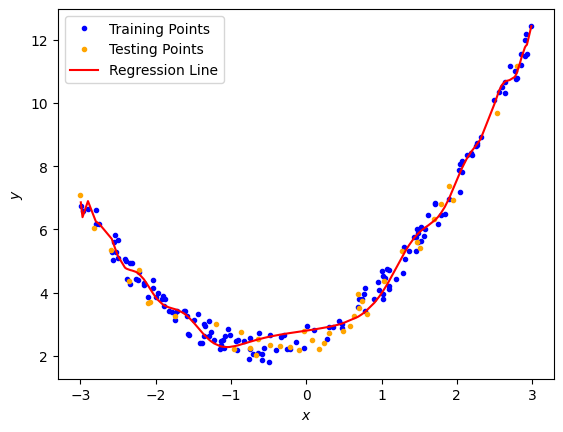

In [47]:
plt.plot(x_train , y_train , 'b.' , label = 'Training Points')
plt.plot(x_test , y_test , '.' , color='orange' , label = 'Testing Points')

# Sort the x values before plotting the regression line
x_sorted = np.sort(x_train, axis=0)
plt.plot(x_sorted , lr.predict(poly.transform(x_sorted)) , 'r-' , label = 'Regression Line')

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show()

In [48]:
poly.powers_

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [12],
       [13],
       [14],
       [15],
       [16],
       [17],
       [18],
       [19],
       [20],
       [21],
       [22],
       [23],
       [24],
       [25],
       [26],
       [27],
       [28],
       [29]])

# **polynomial regression on multiple variable**

In [49]:
# Generate synthetic data with multiple features
np.random.seed(0)
X_multi = 2 * np.random.rand(200, 3)  # 200 samples, 3 features
y_multi = 0.5 + 2 * X_multi[:, 0] + 1.5 * X_multi[:, 1]**2 - 3 * X_multi[:, 2] + np.random.randn(200, 1)

In [50]:
from sklearn.model_selection import train_test_split

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=2)

In [51]:
from sklearn.preprocessing import PolynomialFeatures

poly_multi = PolynomialFeatures(degree=2, include_bias=False)

X_train_multi_poly = poly_multi.fit_transform(X_train_multi)
X_test_multi_poly = poly_multi.transform(X_test_multi)

In [52]:
from sklearn.linear_model import LinearRegression

lr_multi = LinearRegression()
lr_multi.fit(X_train_multi_poly, y_train_multi)

LinearRegression()

In [53]:
from sklearn.metrics import r2_score

y_pred_multi = lr_multi.predict(X_test_multi_poly)
r2_score(y_test_multi, y_pred_multi)

-0.0644324765746377